In [1]:
# ============================================================
# AI Innovators Lab: Handwritten Digit Recognition
# Goal: Train an AI model that can recognize handwritten digits
#       from 0 to 9 using the MNIST dataset.
# Dataset: MNIST
# ============================================================

print("Welcome to the Handwritten Digit Recognition Project!")
print("Goal: Build an AI model that can recognize handwritten numbers from 0 to 9.")

# ============================================================
# Step 1: Import required libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("Libraries loaded successfully!")



Welcome to the Handwritten Digit Recognition Project!
Goal: Build an AI model that can recognize handwritten numbers from 0 to 9.
Libraries loaded successfully!


In [2]:
# ============================================================
# Step 2: Load the MNIST dataset
# MNIST contains thousands of handwritten digit images.
# Each image is 28 x 28 pixels.
# ============================================================

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


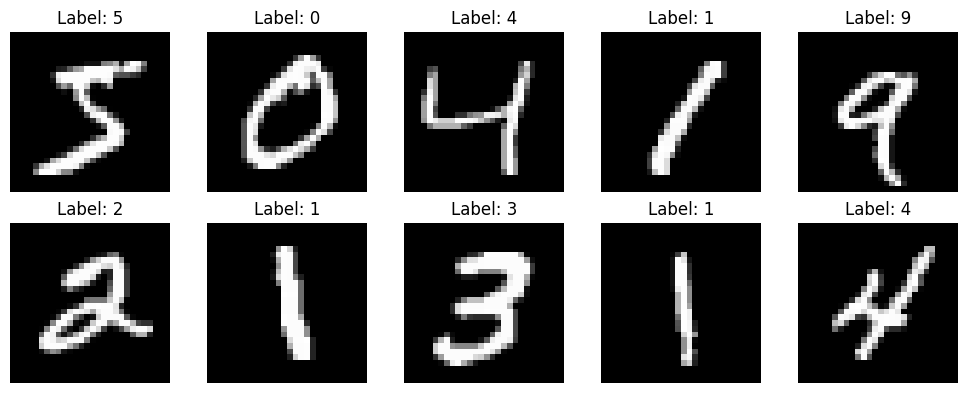

In [3]:
# ============================================================
# Step 3: Display sample images
# This helps students see what the dataset looks like.
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [4]:
# ============================================================
# Step 4: Prepare the data
# Neural networks work better when pixel values are scaled.
# Original pixel values are from 0 to 255.
# We convert them to values between 0 and 1.
# ============================================================

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Data normalized successfully!")



Data normalized successfully!


In [5]:
# ============================================================
# Step 5: Build the AI model
# This is a simple neural network.
# Flatten converts a 28 x 28 image into a list of 784 numbers.
# Dense layers help the model learn patterns.
# ============================================================

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# Step 6: Train the model
# Epoch means how many times the model studies the training data.
# For camp, 5 epochs is enough.
# ============================================================

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

print("Model training completed!")



Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9221 - loss: 0.2612 - val_accuracy: 0.9678 - val_loss: 0.1094
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9664 - loss: 0.1078 - val_accuracy: 0.9675 - val_loss: 0.1072
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0736 - val_accuracy: 0.9778 - val_loss: 0.0781
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9828 - loss: 0.0543 - val_accuracy: 0.9785 - val_loss: 0.0777
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0432 - val_accuracy: 0.9795 - val_loss: 0.0750
Model training completed!


In [7]:
# ============================================================
# Step 7: Test the model
# This checks how well the model performs on new images.
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0761
Test Accuracy: 97.7 %


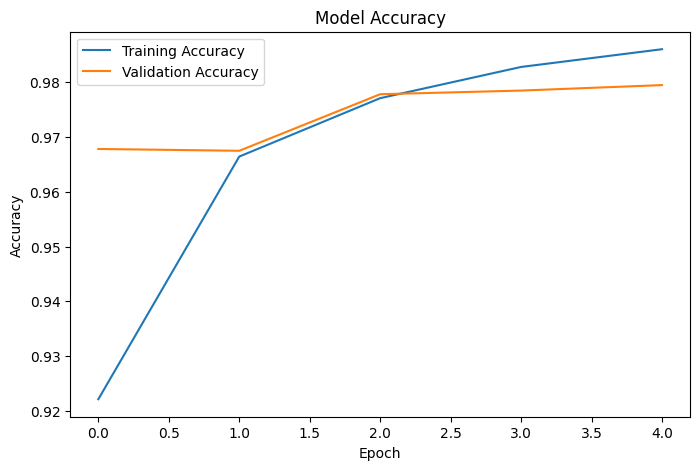

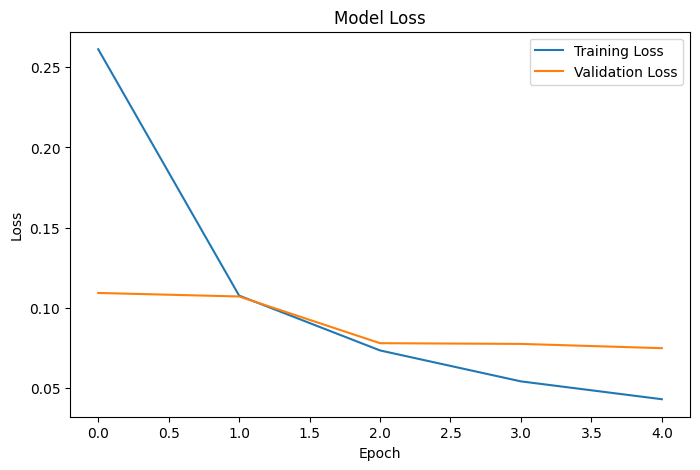

In [8]:
# ============================================================
# Step 8: Plot accuracy and loss
# Accuracy shows how often the model is correct.
# Loss shows how much error the model makes.
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


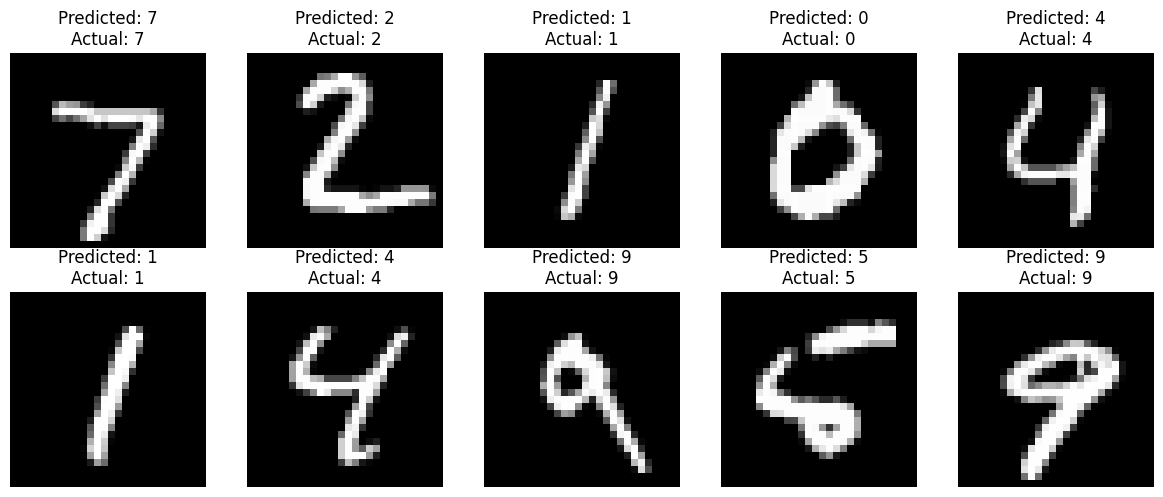

In [9]:
# ============================================================
# Step 9: Make predictions on test images
# The model predicts which digit it sees.
# ============================================================

predictions = model.predict(x_test)

plt.figure(figsize=(12, 5))

for i in range(10):
    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Predicted: {predicted_label}\nActual: {actual_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [10]:
# ============================================================
# Step 10: Draw your own digit in Google Colab
# This creates a simple drawing canvas.
# Students can draw a digit, and the AI will predict it.
# ============================================================

from IPython.display import HTML, display
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io

canvas_html = """
<canvas id="canvas" width="280" height="280" style="border:2px solid black; background-color:white;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="saveCanvas()">Predict Digit</button>

<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = "white";
ctx.fillRect(0, 0, canvas.width, canvas.height);

var drawing = false;

canvas.addEventListener('mousedown', function(e) {
    drawing = true;
    ctx.beginPath();
});

canvas.addEventListener('mouseup', function(e) {
    drawing = false;
});

canvas.addEventListener('mousemove', function(e) {
    if (!drawing) return;
    var rect = canvas.getBoundingClientRect();
    ctx.lineWidth = 18;
    ctx.lineCap = 'round';
    ctx.strokeStyle = 'black';
    ctx.lineTo(e.clientX - rect.left, e.clientY - rect.top);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(e.clientX - rect.left, e.clientY - rect.top);
});

function clearCanvas() {
    ctx.fillStyle = "white";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function saveCanvas() {
    var dataURL = canvas.toDataURL('image/png');
    google.colab.kernel.invokeFunction('notebook.save_digit', [dataURL], {});
}
</script>
"""

drawn_image = None

def save_digit(data_url):
    global drawn_image

    binary = b64decode(data_url.split(",")[1])
    image = Image.open(io.BytesIO(binary)).convert("L")

    # Resize to MNIST size: 28 x 28
    image = image.resize((28, 28))

    # MNIST has white digits on black background.
    # Our canvas has black digit on white background, so we invert it.
    image_array = np.array(image)
    image_array = 255 - image_array

    # Normalize
    image_array = image_array / 255.0

    drawn_image = image_array

    print("Digit saved! Now run the prediction section below.")

from google.colab import output
output.register_callback("notebook.save_digit", save_digit)

display(HTML(canvas_html))



Digit saved! Now run the prediction section below.
Digit saved! Now run the prediction section below.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


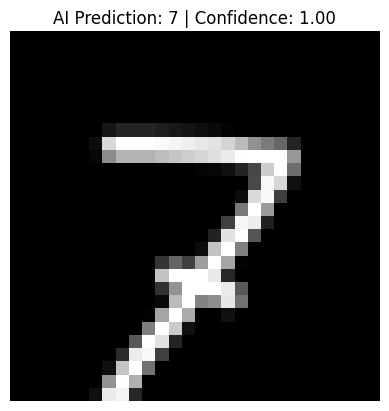

The AI thinks you wrote: 7
Confidence: 100.0 %


In [14]:
# ============================================================
# Step 11: Predict the digit you drew
# Run this after clicking "Predict Digit" on the canvas above.
# ============================================================

if drawn_image is not None:
    input_image = np.expand_dims(drawn_image, axis=0)

    prediction = model.predict(input_image)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.imshow(drawn_image, cmap="gray")
    plt.title(f"AI Prediction: {predicted_digit} | Confidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print("The AI thinks you wrote:", predicted_digit)
    print("Confidence:", round(confidence * 100, 2), "%")
else:
    print("Please draw a digit above and click 'Predict Digit' first.")



In [15]:
# ============================================================
# Step 12: Save the trained model
# Students can keep their AI model.
# ============================================================

model.save("handwritten_digit_recognition_model.h5")

print("Model saved as handwritten_digit_recognition_model.h5")

# ============================================================
# Step 13: Reflection questions for presentation
# Students can answer these in their final showcase.
# ============================================================

reflection_questions = [
    "1. What problem does your AI model solve?",
    "2. What dataset did you use?",
    "3. How did the AI learn from handwritten digits?",
    "4. What was your model accuracy?",
    "5. Did the model make any mistakes?",
    "6. Why might some digits be harder to recognize than others?",
    "7. How could this type of AI be used in real life?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)

Model saved as handwritten_digit_recognition_model.h5

Reflection Questions:
1. What problem does your AI model solve?
2. What dataset did you use?
3. How did the AI learn from handwritten digits?
4. What was your model accuracy?
5. Did the model make any mistakes?
6. Why might some digits be harder to recognize than others?
7. How could this type of AI be used in real life?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Handwritten Digit Recognition AI Model

Team Members:
[Names]

Problem:
We wanted to build an AI model that can recognize handwritten numbers from 0 to 9.

Dataset:
We used the MNIST handwritten digit dataset.

Input:
An image of a handwritten digit

Prediction:
A number from 0 to 9

Model Used:
Neural Network

Result:
Our model reached approximately ____% test accuracy.

Demo:
We drew or uploaded a handwritten digit, and the model predicted the number.

What We Learned:
We learned how AI can recognize patterns in images and classify handwritten numbers.

Future Improvement:
We could train with more handwriting styles, improve image quality, or use a more advanced model.
"""

print(presentation_template)